In [20]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

In [21]:
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(directory='datasets_img',
image_size=(300, 300),
subset='both',
validation_split=0.2,
seed=42)

Found 4240 files belonging to 8 classes.
Using 3392 files for training.
Using 848 files for validation.


In [22]:
test_ds = val_ds.shard(num_shards=2, index=0)
val_ds = val_ds.shard(num_shards=2, index=1)

In [23]:
incv3 = keras.applications.InceptionV3(weights=None,include_top=False,input_shape=(299,299,3))
model = keras.Sequential([
  layers.Input(shape=(28,28,1),name='input'),
  layers.Resizing(299,299),
#   tf.keras.layers.Lambda(tf.image.grayscale_to_rgb),
  incv3_full,
  # layers.GlobalAveragePooling2D(name='gp'),
  layers.Flatten(),
  layers.Dense((1024),activation='relu'),
  layers.Dense((512),activation='relu'),
  layers.Dense((10),activation = 'softmax',name='output')
])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 299, 299, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   134,218,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,551,466 (597.20 MB)

 Trainable params: 156,517,034 (597.07 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [25]:
keras.backend.clear_session(free_memory=True)
model.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


In [26]:
history = model.fit(train_ds,
          batch_size=32,
          epochs=50,
          validation_data=val_ds,
        #   callbacks=callbacks
          )

Epoch 1/50


I0000 00:00:1776919958.096082  920955 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_105065__.683


106/106 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - loss: 4.6222 - sparse_categorical_accuracy: 0.2025 - val_loss: 26799.0293 - val_sparse_categorical_accuracy: 0.1322
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 1.1825 - sparse_categorical_accuracy: 0.5616 - val_loss: 16.1249 - val_sparse_categorical_accuracy: 0.1466
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.7104 - sparse_categorical_accuracy: 0.7391 - val_loss: 1.0207 - val_sparse_categorical_accuracy: 0.7067
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.5564 - sparse_categorical_accuracy: 0.7969 - val_loss: 1.4058 - val_sparse_categorical_accuracy: 0.5913
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.5257 - sparse_categorical_accuracy: 0.8131 - val_loss: 1.6912 - val_sparse_categorical_accuracy: 0.5865
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - loss: 0.4802 - sparse_categorical_accuracy: 0.8281 - val_loss: 1.0644 - val_sparse_categorical_accuracy: 0.6899
Ep

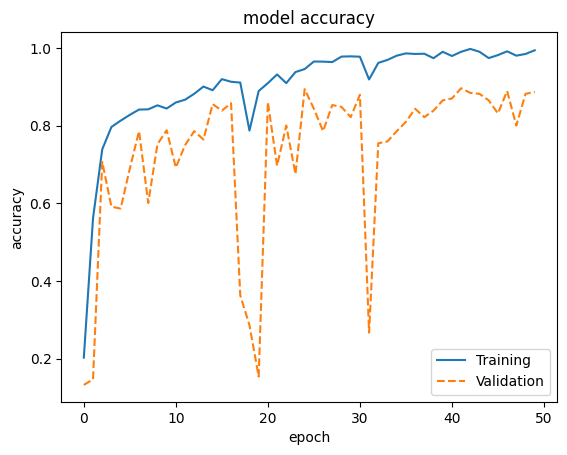

In [28]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [30]:
model.evaluate(test_ds)

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 482ms/step - loss: 0.7786 - sparse_categorical_accuracy: 0.8681


[0.7786330580711365, 0.8680555820465088]